Plot the NN Performance
=======================

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors as colors

import seaborn as sns

In [2]:
df = pd.read_csv('/Users/yuntse/data/lartpc_rd/gampix/nn/radiologicals/gampixpy_fullgeoanatruth-vd-reduced_g4_00_2Mhz_segmentlabel_lowtrig_5mmpitch_good_r3sd_nn0.1.csv', header = 0)
df

,tile_id,event id,trig t,tile x,tile y,charge,fit_amp,fit_mu,fit_sigma,fit_rmse,...,ratio,ratio_3sd,ratio_fit,ratio_fit_3sd,E,z_avg,drift_avg,dQdn,pred_drift,isTraining
0,6,0,-3162.9458,-1055.0,-565.0,645.466084,72.769140,8.629436,2.008671,52.148320,...,1.056047,0.616679,0.973606,0.139099,0.086997,229.34247,95.657530,322.733042,118.079266,True
1,7,0,-3152.9458,-1055.0,-565.0,863.477471,367.460450,0.000000,0.479231,69.086075,...,0.789416,0.460979,0.808135,0.115458,0.086997,229.34247,95.657530,431.738736,86.289760,True
2,8,0,3303.0542,-1055.0,-495.0,206.192841,75.421005,0.703742,0.599231,52.745690,...,1.255070,0.757609,1.078195,0.000000,0.035624,317.78030,7.219696,206.192841,124.997237,True
3,9,0,3329.0542,-1055.0,-495.0,649.875894,357.813400,0.370604,0.491199,57.149880,...,0.372908,0.984344,0.771679,0.756868,0.067363,313.68454,11.315460,649.875894,28.207439,True
4,10,0,3300.5542,-1055.0,-475.0,12670.613630,11144.802000,0.407742,0.224738,27.295210,...,1.024915,0.983099,0.987834,0.987834,0.617345,318.25034,6.749664,6335.306815,2.963651,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
743287,1093431,999,-2328.3333,-745.0,-305.0,2110.563066,570.365970,1.641369,0.697236,51.960224,...,1.056849,0.631141,1.219444,0.632525,0.149259,177.86224,147.137760,703.521022,159.214266,True
743288,1093435,999,-3055.3333,-735.0,-485.0,3129.311161,2286.440000,0.002944,0.343891,21.518084,...,1.126645,0.932051,0.966965,0.959833,0.243623,292.87340,32.126587,1564.655580,32.943541,True
743289,1093437,999,2227.6667,-735.0,-365.0,1105.921688,582.382200,0.061869,0.413435,62.136086,...,0.568188,0.718326,0.864922,0.856996,0.078197,318.09665,6.903351,1105.921688,25.861338,False
743290,1093438,999,2380.6667,-735.0,-355.0,34607.093809,4664.810500,5.653694,1.461395,127.538840,...,0.978621,0.821305,1.019537,0.841994,1.971664,-314.51205,639.512100,2307.139587,615.115194,True


In [3]:
def plot_drift_performance(
    df,
    ref_col = "drift_avg",
    compare_col = "pred_drift",
    bin_width = 25,
    min_entries = 1,
    min_val = 0,
    max_val = 650
):
    """
    Make violin, bias, resolution, relative bias, and relative resolution plots.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe containing truth and prediction columns.
    truth_col : str
        Column name for true/reference value.
    pred_col : str
        Column name for predicted value.
    bin_width : float
        Width of truth bins, e.g. 20 for 20 cm bins.
    min_entries : int
        Minimum number of entries required in a bin to keep it.
    figsize_violin : tuple
        Figure size for violin plot.
    figsize_summary : tuple
        Figure size for summary plots.

    Returns
    -------
    work_df : pandas.DataFrame
        Copy of input dataframe with derived columns.
    summary : pandas.DataFrame
        Summary table with quantiles and derived metrics.
    """

    work_df = df.copy()

    # keep only finite values
    work_df = work_df[np.isfinite(work_df[ref_col]) & np.isfinite(work_df[compare_col])].copy()

    # derived columns
    work_df["diff"] = work_df[compare_col] - work_df[ref_col]

    # for relative quantities avoid division by zero
    work_df["rel_diff"] = np.nan
    nonzero = work_df[ref_col] != 0
    work_df.loc[nonzero, "rel_diff"] = (
        work_df.loc[nonzero, "diff"] / work_df.loc[nonzero, ref_col]
    )

    # define bins
    # min_val = np.floor(work_df[truth_col].min() / bin_width) * bin_width
    # max_val = np.ceil(work_df[truth_col].max() / bin_width) * bin_width
    bins = np.arange(min_val, max_val + bin_width, bin_width)

    work_df["drift_bin"] = pd.cut(work_df[ref_col], bins = bins, right = False)

    # remove empty / too-small bins
    counts = work_df["drift_bin"].value_counts().sort_index()
    valid_bins = counts[counts >= min_entries].index
    work_df = work_df[work_df["drift_bin"].isin(valid_bins)].copy()

    # ordered labels for plotting
    work_df["drift_bin_label"] = work_df["drift_bin"].apply(
        lambda x: f"[{int(x.left)}, {int(x.right)})"
    )

    # absolute summary
    abs_summary = (
        work_df.groupby("drift_bin")["diff"]
        .quantile([0.16, 0.50, 0.84])
        .unstack()
        .rename(columns = {0.16: "diff_q16", 0.50: "diff_q50", 0.84: "diff_q84"})
    )

    # relative summary
    rel_summary = (
        work_df.dropna(subset = ["rel_diff"])
        .groupby("drift_bin")["rel_diff"]
        .quantile([0.16, 0.50, 0.84])
        .unstack()
        .rename(columns = {0.16: "rel_q16", 0.50: "rel_q50", 0.84: "rel_q84"})
    )

    # counts and x positions
    count_summary = work_df.groupby("drift_bin").size().to_frame("count")

    summary = abs_summary.join(rel_summary, how = "left").join(count_summary, how = "left").reset_index()

    summary["x_center"] = summary["drift_bin"].apply(lambda b: (b.left + b.right) / 2)
    summary["bin_label"] = summary["drift_bin"].apply(lambda b: f"[{int(b.left)}, {int(b.right)})")

    # absolute bias/resolution
    summary["bias"] = summary["diff_q50"]
    summary["bias_err_low"] = summary["diff_q50"] - summary["diff_q16"]
    summary["bias_err_high"] = summary["diff_q84"] - summary["diff_q50"]
    summary["resolution"] = (summary["diff_q84"] - summary["diff_q16"]) / 2.0

    # relative bias/resolution
    summary["rel_bias"] = summary["rel_q50"]
    summary["rel_bias_err_low"] = summary["rel_q50"] - summary["rel_q16"]
    summary["rel_bias_err_high"] = summary["rel_q84"] - summary["rel_q50"]
    summary["rel_resolution"] = (summary["rel_q84"] - summary["rel_q16"]) / 2.0
    
    return work_df, summary

## Performance plots w.r.t. predicted drift distance

In [4]:
work_df, summary = plot_drift_performance(
    df,
    ref_col = "pred_drift",
    compare_col = "drift_avg",
    bin_width = 25
)

/var/folders/bn/24gl1c290ls54cq54cz7rt9sfm8jyc/T/ipykernel_5897/1868138495.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  work_df.groupby("drift_bin")["diff"]
/var/folders/bn/24gl1c290ls54cq54cz7rt9sfm8jyc/T/ipykernel_5897/1868138495.py:81: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("drift_bin")["rel_diff"]
/var/folders/bn/24gl1c290ls54cq54cz7rt9sfm8jyc/T/ipykernel_5897/1868138495.py:88: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future defau

In [5]:
figsize_violin = (12, 6)
figsize_summary = (8, 5)

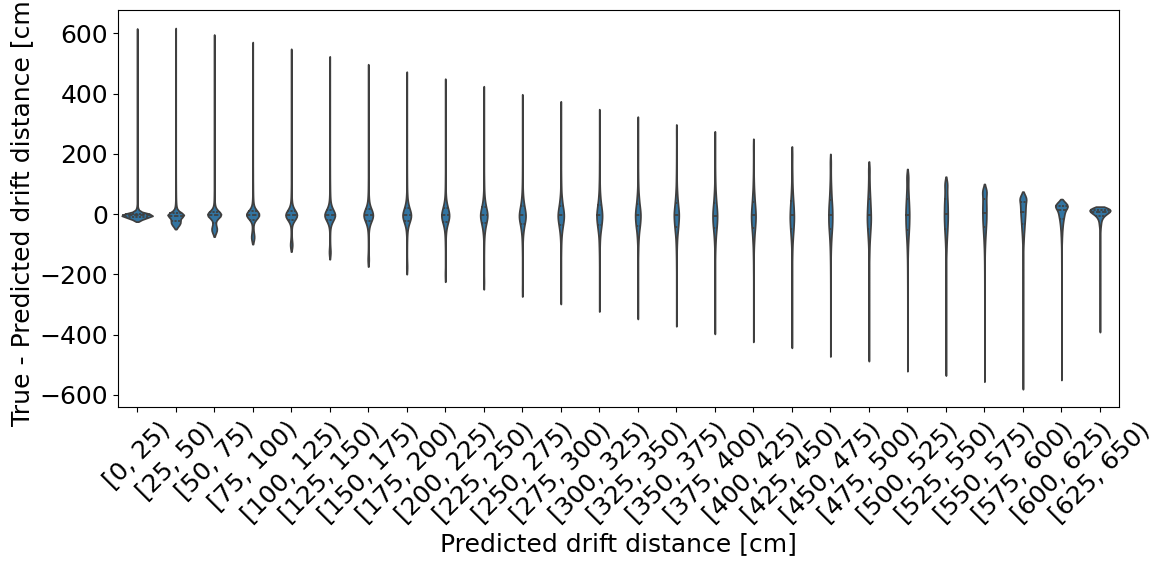

In [14]:
# --------------------
# 1. Violin plot
# --------------------
plt.rcParams.update({"font.size": 18,
                     "axes.labelsize": 18,
                     "xtick.labelsize": 18,
                     "ytick.labelsize": 18,})
fig, ax = plt.subplots(figsize = figsize_violin)

sns.violinplot(
    data = work_df,
    x = "drift_bin_label",
    y = "diff",
    inner = "quartile",
    cut = 0,
    ax = ax
)
ax.set_xlabel(f"Predicted drift distance [cm]")
ax.set_ylabel(f"True - Predicted drift distance [cm]")
# ax.set_title("Distribution of prediction residuals by truth bin")
ax.tick_params(axis = "x", labelrotation = 45)
plt.tight_layout()
plt.show()

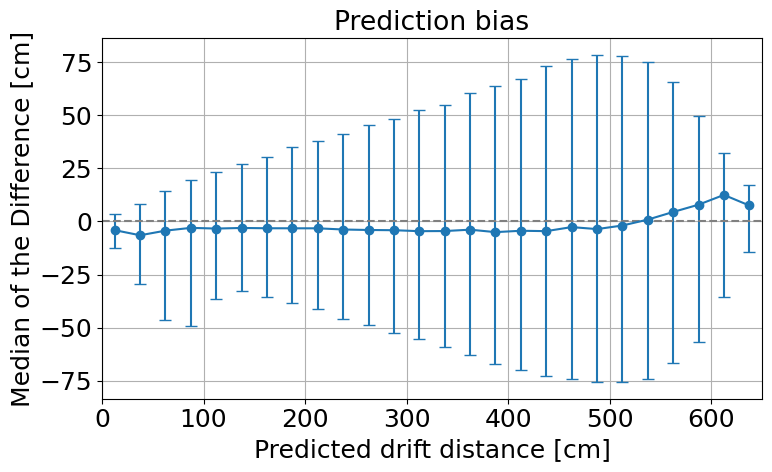

In [7]:
# --------------------
# 2. Bias plot
# --------------------
fig, ax = plt.subplots(figsize = figsize_summary)
plt.rcParams.update({"font.size": 16})

ax.errorbar(
    summary["x_center"],
    summary["bias"],
    yerr = [summary["bias_err_low"], summary["bias_err_high"]],
    fmt = "o-",
    capsize = 4
)

ax.axhline(0, color = "gray", linestyle = "--")
ax.set_xlabel("Predicted drift distance [cm]")
ax.set_ylabel("Median of the Difference [cm]")
ax.set_title("Prediction bias")
ax.set_xlim([0, 650])
ax.grid()
    
plt.tight_layout()
plt.show()

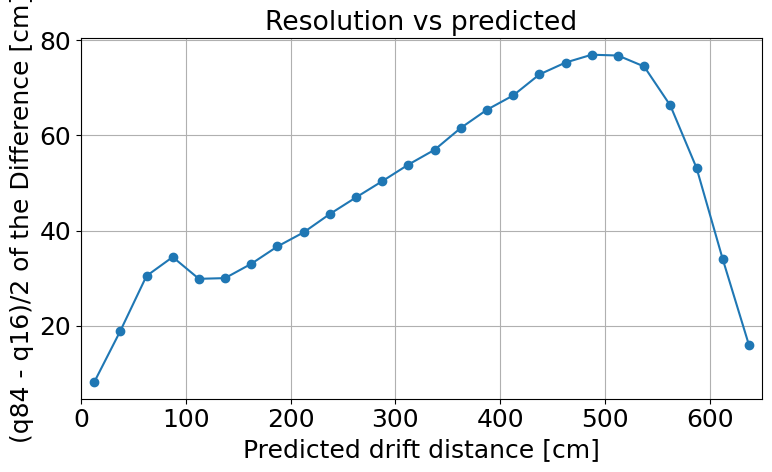

In [8]:
# --------------------
# 3. Resolution plot
# --------------------
fig, ax = plt.subplots(figsize = figsize_summary)
plt.rcParams.update({"font.size": 16})

ax.plot(summary["x_center"], summary["resolution"], "o-")
ax.set_xlabel("Predicted drift distance [cm]")
ax.set_ylabel("(q84 - q16)/2 of the Difference [cm]")
ax.set_title("Resolution vs predicted")
ax.set_xlim([0, 650])
ax.grid()

plt.tight_layout()
plt.show()

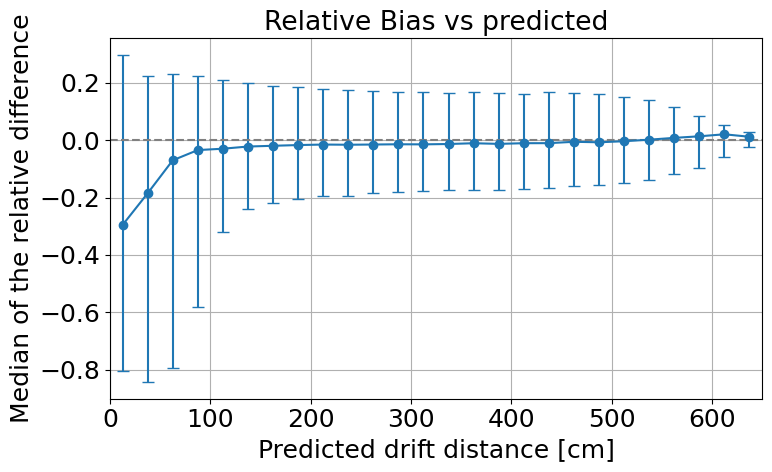

In [9]:
# --------------------
# 4. Relative bias plot
# --------------------
fig, ax = plt.subplots(figsize = figsize_summary)
plt.rcParams.update({"font.size": 16})

ax.errorbar(
    summary["x_center"],
    summary["rel_bias"],
    yerr = [summary["rel_bias_err_low"], summary["rel_bias_err_high"]],
    fmt = "o-",
    capsize = 4
)

ax.axhline(0, color = "gray", linestyle = "--")
ax.set_xlabel("Predicted drift distance [cm]")
ax.set_ylabel(f"Median of the relative difference")
ax.set_title("Relative Bias vs predicted")
ax.set_xlim([0, 650])
ax.grid()
# ax.set_yscale('log')
plt.tight_layout()
plt.show()

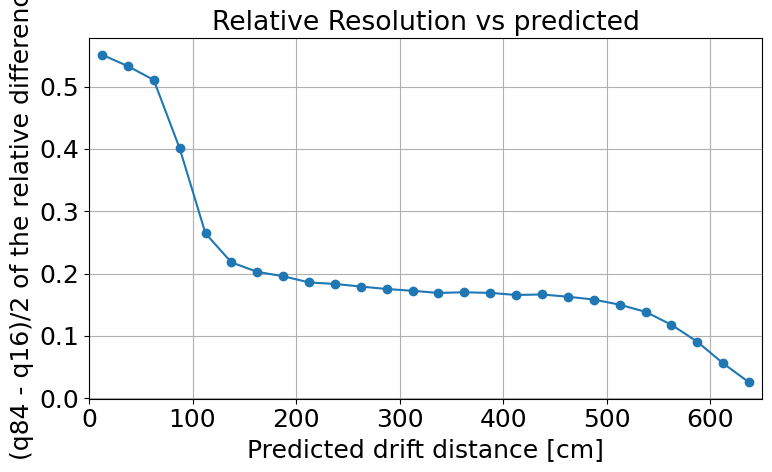

In [10]:
# ---------------------------
# 5. Relative resolution plot
# ---------------------------
fig, ax = plt.subplots(figsize = figsize_summary)
plt.rcParams.update({"font.size": 16})

ax.plot(summary["x_center"], summary["rel_resolution"], "o-")
ax.set_xlabel("Predicted drift distance [cm]")
ax.set_ylabel("(q84 - q16)/2 of the relative difference")
ax.set_title("Relative Resolution vs predicted")
ax.set_xlim([0, 650])
ax.grid()
# ax.set_yscale('log')
plt.tight_layout()
plt.show()

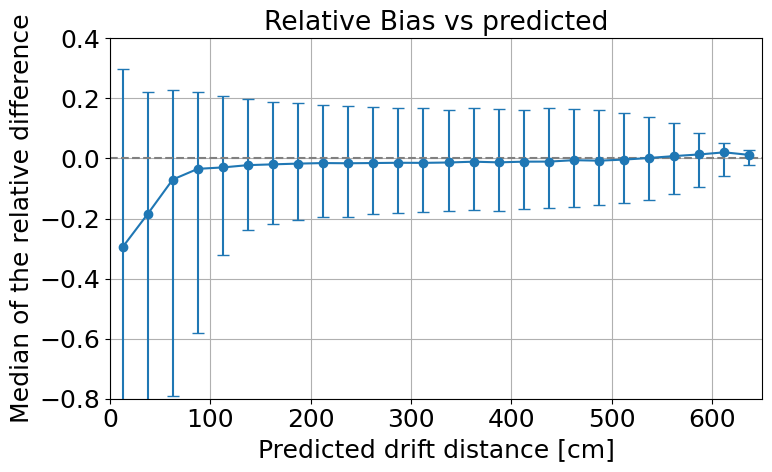

In [ ]:
# --------------------------------------------
# 6. Relative bias plot - y range [-0.8, 0.4]
# --------------------------------------------
fig, ax = plt.subplots(figsize = figsize_summary)
plt.rcParams.update({"font.size": 16})

ax.errorbar(
    summary["x_center"],
    summary["rel_bias"],
    yerr = [summary["rel_bias_err_low"], summary["rel_bias_err_high"]],
    fmt = "o-",
    capsize = 4
)

ax.axhline(0, color = "gray", linestyle = "--")
ax.set_xlabel("Predicted drift distance [cm]")
ax.set_ylabel(f"Median of the relative difference")
ax.set_title("Relative Bias vs predicted")
ax.set_xlim([0, 650])
ax.set_ylim([-0.8, 0.4])
ax.grid()
# ax.set_yscale('log')
plt.tight_layout()
plt.show()

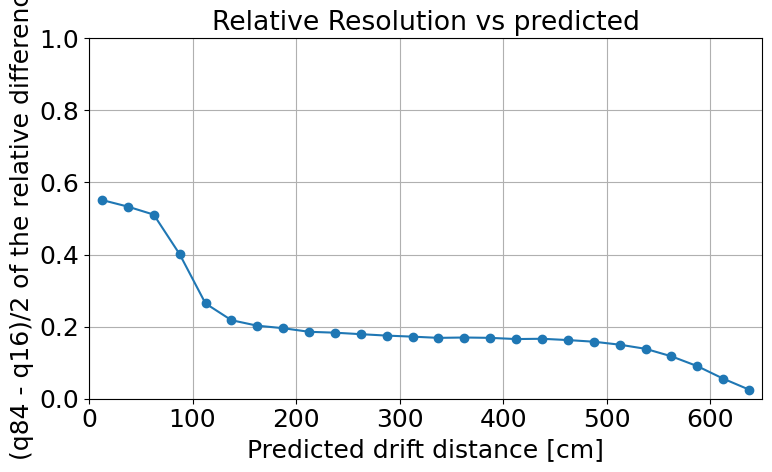

In [12]:
# --------------------------------------------------
# 7. Relative resolution plot - y range [0, 1]
# --------------------------------------------------
fig, ax = plt.subplots(figsize = figsize_summary)
plt.rcParams.update({"font.size": 16})

ax.plot(summary["x_center"], summary["rel_resolution"], "o-")
ax.set_xlabel("Predicted drift distance [cm]")
ax.set_ylabel("(q84 - q16)/2 of the relative difference")
ax.set_title("Relative Resolution vs predicted")
ax.set_xlim([0, 650])
ax.set_ylim([0, 1])
ax.grid()
# ax.set_yscale('log')
plt.tight_layout()
plt.show()

## Performance plots w.r.t. true drift distance

In [13]:
work_df_true, summary_true = plot_drift_performance(
    df,
    ref_col = "drift_avg",
    compare_col = "pred_drift",
    bin_width = 25
)

/var/folders/bn/24gl1c290ls54cq54cz7rt9sfm8jyc/T/ipykernel_5897/1868138495.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  work_df.groupby("drift_bin")["diff"]
/var/folders/bn/24gl1c290ls54cq54cz7rt9sfm8jyc/T/ipykernel_5897/1868138495.py:81: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("drift_bin")["rel_diff"]
/var/folders/bn/24gl1c290ls54cq54cz7rt9sfm8jyc/T/ipykernel_5897/1868138495.py:88: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future defau

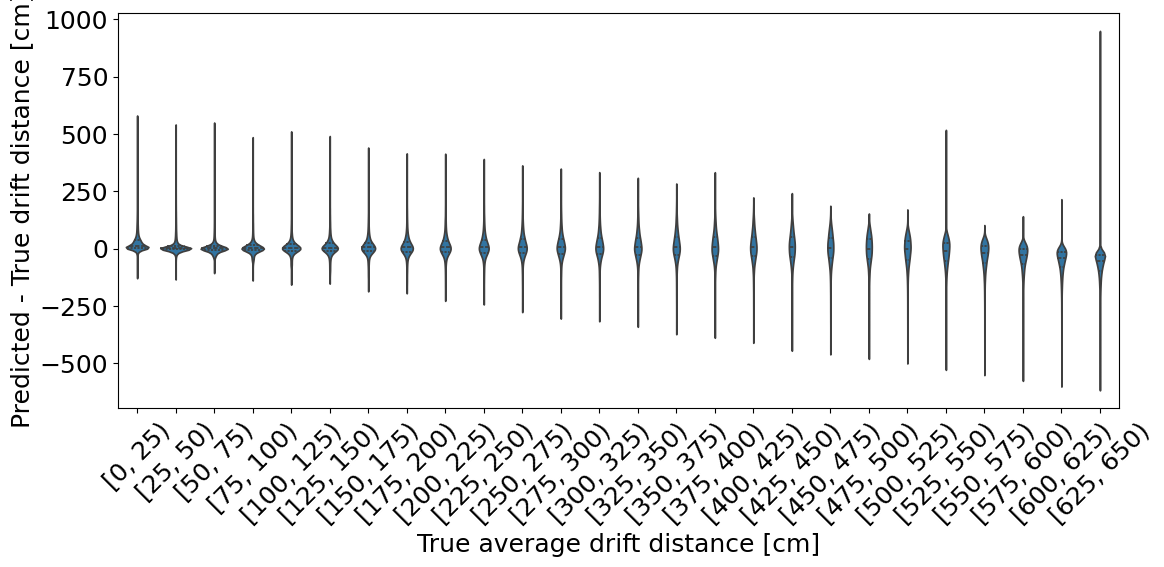

In [15]:
# --------------------
# 1. Violin plot
# --------------------
plt.rcParams.update({"font.size": 18,
                     "axes.labelsize": 18,
                     "xtick.labelsize": 18,
                     "ytick.labelsize": 18,})
fig, ax = plt.subplots(figsize = figsize_violin)

sns.violinplot(
    data = work_df_true,
    x = "drift_bin_label",
    y = "diff",
    inner = "quartile",
    cut = 0,
    ax = ax
)
ax.set_xlabel(f"True average drift distance [cm]")
ax.set_ylabel(f"Predicted - True drift distance [cm]")
# ax.set_title("Distribution of prediction residuals by truth bin")
ax.tick_params(axis = "x", labelrotation = 45)
plt.tight_layout()
plt.show()

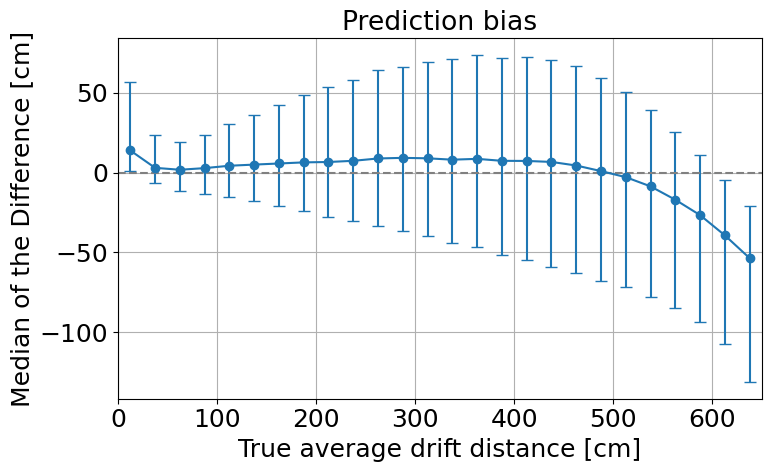

In [16]:
# --------------------
# 2. Bias plot
# --------------------
fig, ax = plt.subplots(figsize = figsize_summary)
plt.rcParams.update({"font.size": 16})

ax.errorbar(
    summary_true["x_center"],
    summary_true["bias"],
    yerr = [summary_true["bias_err_low"], summary_true["bias_err_high"]],
    fmt = "o-",
    capsize = 4
)

ax.axhline(0, color = "gray", linestyle = "--")
ax.set_xlabel("True average drift distance [cm]")
ax.set_ylabel("Median of the Difference [cm]")
ax.set_title("Prediction bias")
ax.set_xlim([0, 650])
ax.grid()
    
plt.tight_layout()
plt.show()

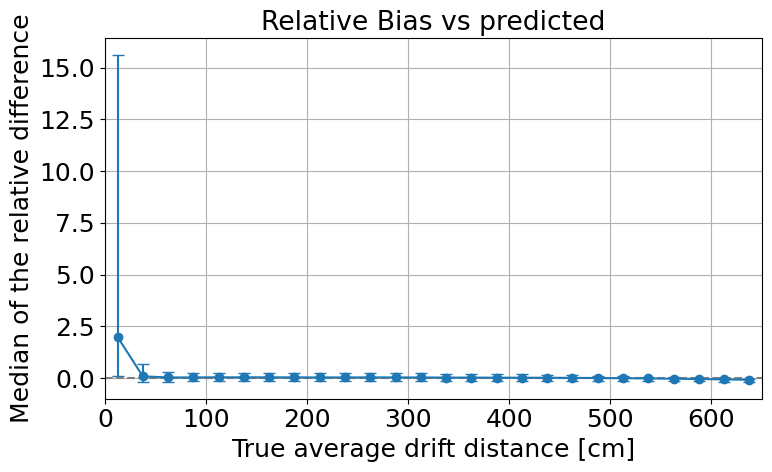

In [ ]:
# --------------------
# 4. Relative bias plot
# --------------------
fig, ax = plt.subplots(figsize = figsize_summary)
plt.rcParams.update({"font.size": 16})

ax.errorbar(
    summary_true["x_center"],
    summary_true["rel_bias"],
    yerr = [summary_true["rel_bias_err_low"], summary_true["rel_bias_err_high"]],
    fmt = "o-",
    capsize = 4
)

ax.axhline(0, color = "gray", linestyle = "--")
ax.set_xlabel("True average drift distance [cm]")
ax.set_ylabel(f"Median of the relative difference")
ax.set_title("Relative Bias vs predicted")
ax.set_xlim([0, 650])
ax.grid()
# ax.set_yscale('log')
plt.tight_layout()
plt.show()

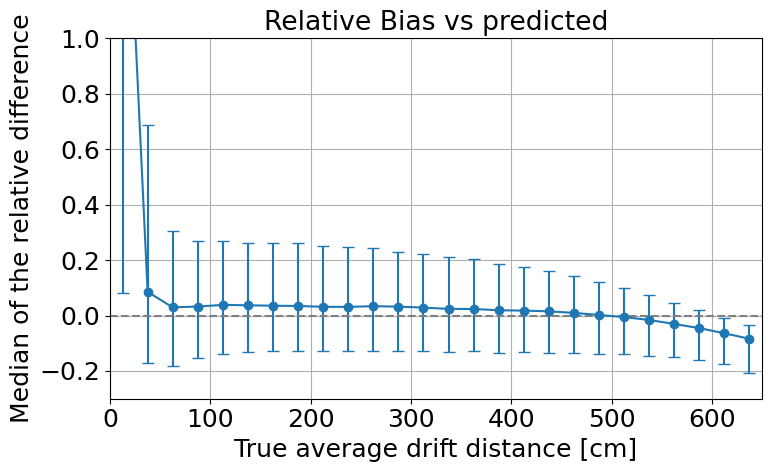

In [21]:
# --------------------------------------------
# 6. Relative bias plot - y range [-0.3, 1]
# --------------------------------------------
fig, ax = plt.subplots(figsize = figsize_summary)
plt.rcParams.update({"font.size": 16})

ax.errorbar(
    summary_true["x_center"],
    summary_true["rel_bias"],
    yerr = [summary_true["rel_bias_err_low"], summary_true["rel_bias_err_high"]],
    fmt = "o-",
    capsize = 4
)

ax.axhline(0, color = "gray", linestyle = "--")
ax.set_xlabel("True average drift distance [cm]")
ax.set_ylabel(f"Median of the relative difference")
ax.set_title("Relative Bias vs predicted")
ax.set_xlim([0, 650])
ax.set_ylim([-0.3, 1])
ax.grid()
# ax.set_yscale('log')
plt.tight_layout()
plt.show()

## Comparison of Tile+Pixel results and Pixel-only results

W.r.t. true drift distance

In [22]:
df_noTile = pd.read_csv('/Users/yuntse/data/lartpc_rd/gampix/nn/radiologicals/gampixpy_fullgeoanatruth-vd-reduced_g4_00_2Mhz_segmentlabel_lowtrig_5mmpitch_good_r3sd_nn0.1_noTile.csv', header = 0)
df_noTile

,tile_id,event id,trig t,tile x,tile y,charge,fit_amp,fit_mu,fit_sigma,fit_rmse,...,ratio_fit,ratio_fit_3sd,E,z_avg,drift_avg,dQdn,ratio_3sd_pixel,dQdn_pixel,pred_drift,isTraining
0,6,0,-3162.9458,-1055.0,-565.0,645.466084,72.769140,8.629436,2.008671,52.148320,...,0.973606,0.139099,0.086997,229.34247,95.657530,322.733042,0.583950,340.821264,165.033581,True
1,7,0,-3152.9458,-1055.0,-565.0,863.477471,367.460450,0.000000,0.479231,69.086075,...,0.808135,0.115458,0.086997,229.34247,95.657530,431.738736,0.583950,340.821264,165.033581,True
2,8,0,3303.0542,-1055.0,-495.0,206.192841,75.421005,0.703742,0.599231,52.745690,...,1.078195,0.000000,0.035624,317.78030,7.219696,206.192841,0.603639,258.786415,210.072704,True
3,10,0,3300.5542,-1055.0,-475.0,12670.613630,11144.802000,0.407742,0.224738,27.295210,...,0.987834,0.987834,0.617345,318.25034,6.749664,6335.306815,0.959200,6493.149974,-0.169305,True
4,13,0,3336.0542,-1045.0,-565.0,3145.416681,536.625100,3.074732,1.146265,44.676376,...,1.274494,0.321890,0.271025,-162.54642,487.546420,524.236114,0.288821,605.980349,506.828687,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725788,1093434,999,-3065.3333,-735.0,-485.0,751.876325,492.074620,9.500000,0.396534,97.148110,...,5.288097,4.441983,0.243623,292.87340,32.126587,187.969081,0.776965,1202.721404,150.629291,True
725789,1093435,999,-3055.3333,-735.0,-485.0,3129.311161,2286.440000,0.002944,0.343891,21.518084,...,0.966965,0.959833,0.243623,292.87340,32.126587,1564.655580,0.827281,1762.810752,58.346710,True
725790,1093438,999,2380.6667,-735.0,-355.0,34607.093809,4664.810500,5.653694,1.461395,127.538840,...,1.019537,0.841994,1.971664,-314.51205,639.512100,2307.139587,0.839247,2257.815613,643.950814,False
725791,1093439,999,2405.6667,-735.0,-355.0,424.614502,90.735000,6.321275,0.543400,45.504536,...,20.965773,0.000000,0.409103,-319.75740,644.757400,60.659215,0.160300,586.261347,592.068561,True


In [23]:
work_df_true_noTile, summary_true_noTile = plot_drift_performance(
    df_noTile,
    ref_col = "drift_avg",
    compare_col = "pred_drift",
    bin_width = 25
)

/var/folders/bn/24gl1c290ls54cq54cz7rt9sfm8jyc/T/ipykernel_5897/1868138495.py:72: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  work_df.groupby("drift_bin")["diff"]
/var/folders/bn/24gl1c290ls54cq54cz7rt9sfm8jyc/T/ipykernel_5897/1868138495.py:81: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("drift_bin")["rel_diff"]
/var/folders/bn/24gl1c290ls54cq54cz7rt9sfm8jyc/T/ipykernel_5897/1868138495.py:88: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future defau

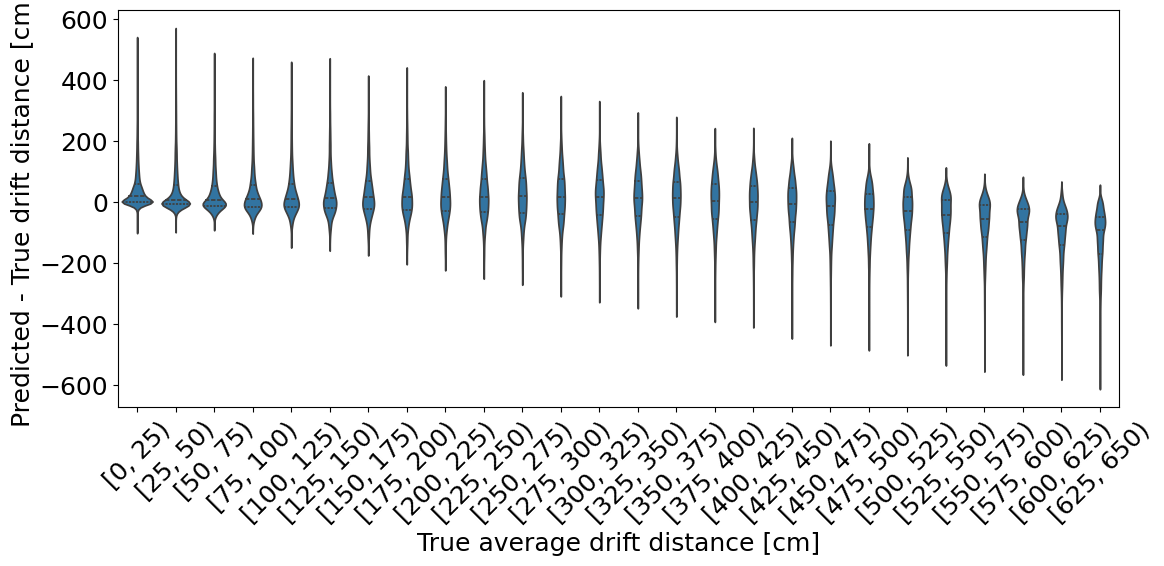

In [24]:
# --------------------
# 1. Violin plot
# --------------------
plt.rcParams.update({"font.size": 18,
                     "axes.labelsize": 18,
                     "xtick.labelsize": 18,
                     "ytick.labelsize": 18,})
fig, ax = plt.subplots(figsize = figsize_violin)

sns.violinplot(
    data = work_df_true_noTile,
    x = "drift_bin_label",
    y = "diff",
    inner = "quartile",
    cut = 0,
    ax = ax
)
ax.set_xlabel(f"True average drift distance [cm]")
ax.set_ylabel(f"Predicted - True drift distance [cm]")
# ax.set_title("Distribution of prediction residuals by truth bin")
ax.tick_params(axis = "x", labelrotation = 45)
plt.tight_layout()
plt.show()

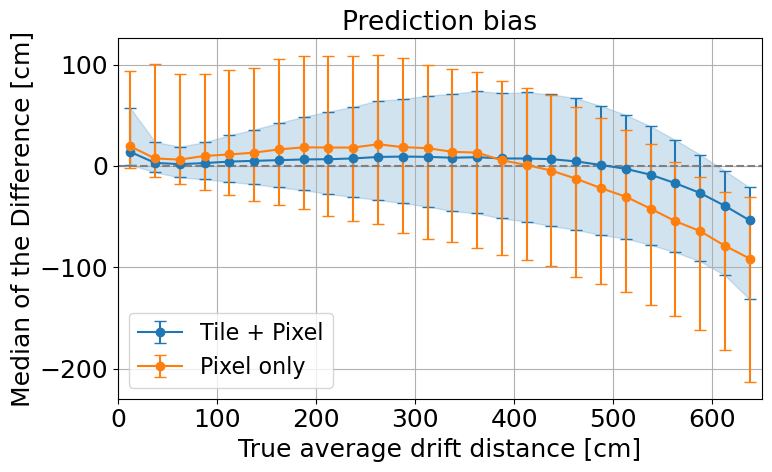

In [28]:
# --------------------
# 2. Bias plot
# --------------------
fig, ax = plt.subplots(figsize = figsize_summary)
plt.rcParams.update({"font.size": 16})

ax.errorbar(
    summary_true["x_center"],
    summary_true["bias"],
    yerr = [summary_true["bias_err_low"], summary_true["bias_err_high"]],
    fmt = "o-",
    capsize = 4,
    label = 'Tile + Pixel'
)
ax.fill_between(summary_true["x_center"], summary_true["bias"] - summary_true["bias_err_low"], summary_true["bias"] + summary_true["bias_err_high"], color = 'tab:blue', alpha = 0.2)

ax.errorbar(
    summary_true_noTile["x_center"],
    summary_true_noTile["bias"],
    yerr = [summary_true_noTile["bias_err_low"], summary_true_noTile["bias_err_high"]],
    fmt = "o-",
    capsize = 4,
    label = 'Pixel only'
)


ax.axhline(0, color = "gray", linestyle = "--")
ax.set_xlabel("True average drift distance [cm]")
ax.set_ylabel("Median of the Difference [cm]")
ax.set_title("Prediction bias")
ax.set_xlim([0, 650])
ax.grid()
ax.legend()
    
plt.tight_layout()
plt.show()

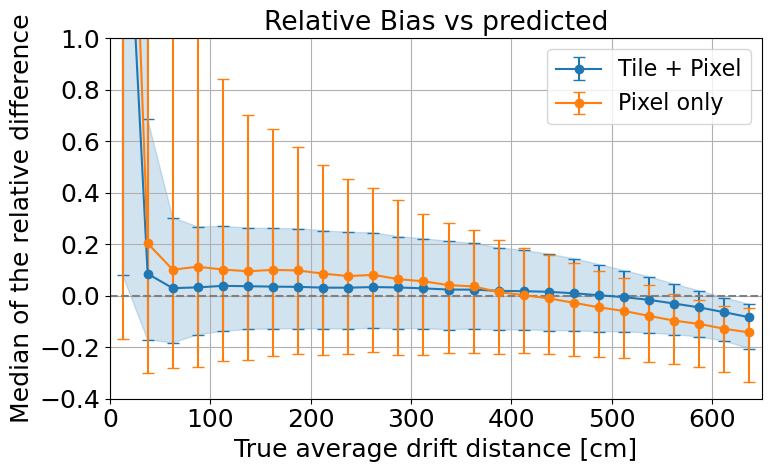

In [34]:
# --------------------
# 4. Relative bias plot
# --------------------
fig, ax = plt.subplots(figsize = figsize_summary)
plt.rcParams.update({"font.size": 16})

ax.errorbar(
    summary_true["x_center"],
    summary_true["rel_bias"],
    yerr = [summary_true["rel_bias_err_low"], summary_true["rel_bias_err_high"]],
    fmt = "o-",
    capsize = 4,
    label = 'Tile + Pixel'
)
ax.fill_between(summary_true["x_center"], summary_true["rel_bias"] - summary_true["rel_bias_err_low"], summary_true["rel_bias"] + summary_true["rel_bias_err_high"], color = 'tab:blue', alpha = 0.2)

ax.errorbar(
    summary_true_noTile["x_center"],
    summary_true_noTile["rel_bias"],
    yerr = [summary_true_noTile["rel_bias_err_low"], summary_true_noTile["rel_bias_err_high"]],
    fmt = "o-",
    capsize = 4,
    label = 'Pixel only'
)

ax.axhline(0, color = "gray", linestyle = "--")
ax.set_xlabel("True average drift distance [cm]")
ax.set_ylabel(f"Median of the relative difference")
ax.set_title("Relative Bias vs predicted")
ax.set_xlim([0, 650])
ax.set_ylim([-0.4, 1])
ax.grid()
# ax.set_yscale('log')
ax.legend()

plt.tight_layout()
plt.show()